Bibliotecas

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import numpy as np

---

Importando os dados


In [19]:
df = pd.read_csv('13_30_11-Dados.csv')

df

,millis,lat,lon,sat,alt,data,hora,altp,p,ax,ay,az,gx,gy,gz,pqd
0,7060,-22.590936,-42.764552,10,11.7,NaN,13:30:11,-0.10,1026.58,1.99,9.19,0.83,-0.08,0.01,0.00,0
1,7260,-22.590936,-42.764552,10,11.7,NaN,13:30:11,0.03,1026.57,1.91,9.36,0.71,-0.06,0.02,0.03,0
2,7460,-22.590936,-42.764552,10,11.7,NaN,13:30:11,-0.11,1026.59,1.99,9.40,0.89,-0.08,0.06,0.02,0
3,7660,-22.590936,-42.764552,10,11.7,NaN,13:30:11,-0.11,1026.59,1.79,9.26,0.91,-0.09,0.03,0.02,0
4,7911,-22.590937,-42.764552,10,11.7,2025/6/2,13:30:13,-0.30,1026.61,1.94,9.57,1.23,-0.12,0.03,0.07,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1867,475590,-22.590632,-42.765445,12,8.4,2025/6/2,13:38:0,109.49,1013.32,1.03,-4.33,-1.12,-0.23,0.78,0.25,0
1868,476463,-22.590503,-42.765532,11,-23.6,2025/6/2,13:38:1,65.33,1018.65,0.28,-5.04,-2.01,-0.20,0.93,0.32,1
1869,476706,-22.590503,-42.765532,11,-23.6,2025/6/2,13:38:1,51.02,1020.38,1.26,-5.34,-1.35,-0.21,0.54,0.06,1
1870,476947,-22.590379,-42.765614,11,-23.6,2025/6/2,13:38:2,36.58,1022.13,0.63,-5.48,0.39,0.03,0.48,0.04,1


---

Filtrando os dados de voo

In [20]:
threshold = df['altp'].mean() - 4
df_filtered = df[df['altp'] > threshold]

---

Obtendo o tempo de atividade

In [21]:
tempo_ativo = df['millis'].iloc[-1] - df['millis'].iloc[0]
tempo_ativo = tempo_ativo / 60000 # Tempo ativo em minutos

df_filtered.loc[:, 'millis'] = df_filtered['millis'] - df_filtered['millis'].iloc[0]
df_filtered['millis'] = df_filtered['millis'] / 1000  # Convertendo para segundos
df_filtered.to_csv('dados_filtrados.csv', index=False)
tempo_voo = df_filtered['millis'].iloc[-1] - df_filtered['millis'].iloc[0]
tempo_voo = tempo_voo

print(f'Tempo ativo: {tempo_ativo:.2f} minutos')
print(f'Tempo de voo: {tempo_voo:.2f} segundos')

Tempo ativo: 7.84 minutos
Tempo de voo: 15.45 segundos


---

Dados do BMP280

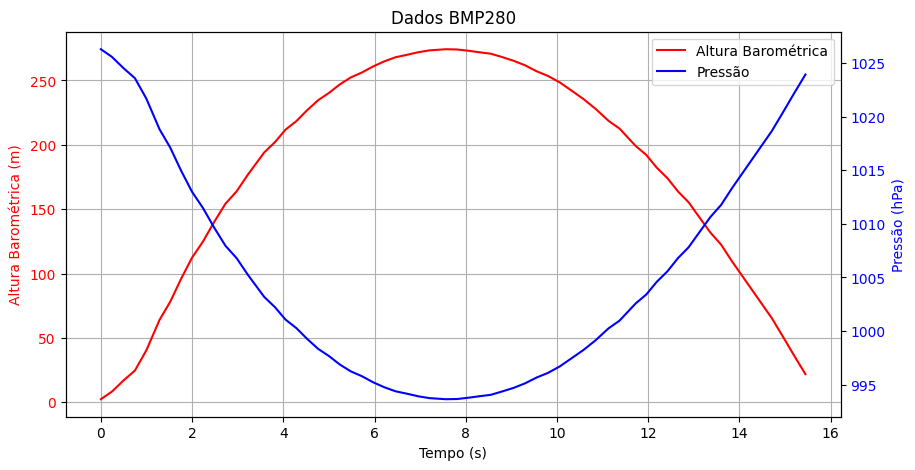

In [22]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(df_filtered['millis'], df_filtered['altp'], label='Altura Barométrica', color='red')
ax1.set_xlabel('Tempo (s)')
ax1.set_ylabel('Altura Barométrica (m)', color='red')
ax1.tick_params(axis='y', labelcolor='red')
ax1.grid()

ax2 = ax1.twinx()
ax2.plot(df_filtered['millis'], df_filtered['p'], label='Pressão', color='blue')
ax2.set_ylabel('Pressão (hPa)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# Legendas para ambos os eixos
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.title('Dados BMP280')
plt.show()

---

Altura máxima

In [23]:
alt_max = df_filtered['altp'].max()

print(f'Altura máxima barométrica: {alt_max:.2f} m')

Altura máxima barométrica: 274.23 m


---

Acionamento do paraquedas

In [24]:
pqd_index = df_filtered[df_filtered['pqd'] == 1].index[0]
pqd_alt = df_filtered.loc[pqd_index, 'altp']
pqd_time = df_filtered.loc[pqd_index, 'millis']

print(f'Paraquedas aberto: {pqd_alt:.2f} m')

Paraquedas aberto: 65.33 m


---

Trajetória 1D

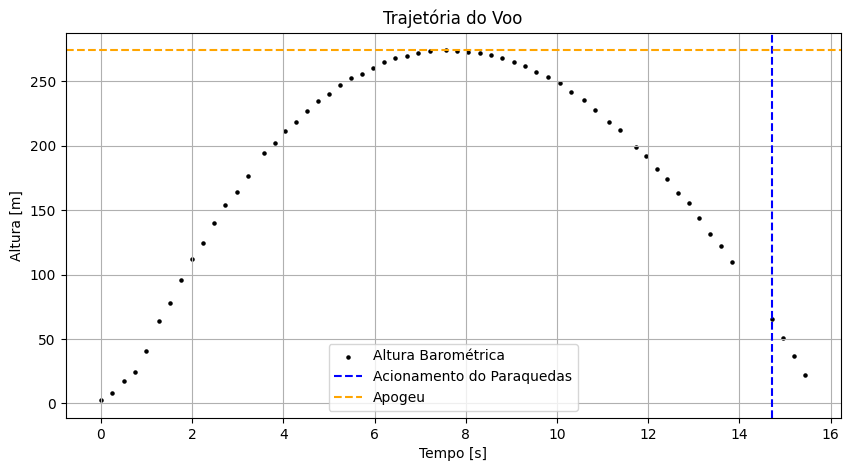

In [25]:
plt.figure(figsize=(10, 5))
plt.scatter(df_filtered['millis'], df_filtered['altp'], label='Altura Barométrica', color='black', s=5)
plt.axvline(x=pqd_time, color='blue', linestyle='--', label='Acionamento do Paraquedas')
plt.axhline(y=alt_max, color='orange', linestyle='--', label='Apogeu')
plt.title('Trajetória do Voo')
plt.xlabel('Tempo [s]')
plt.ylabel('Altura [m]')
plt.legend()
plt.grid()

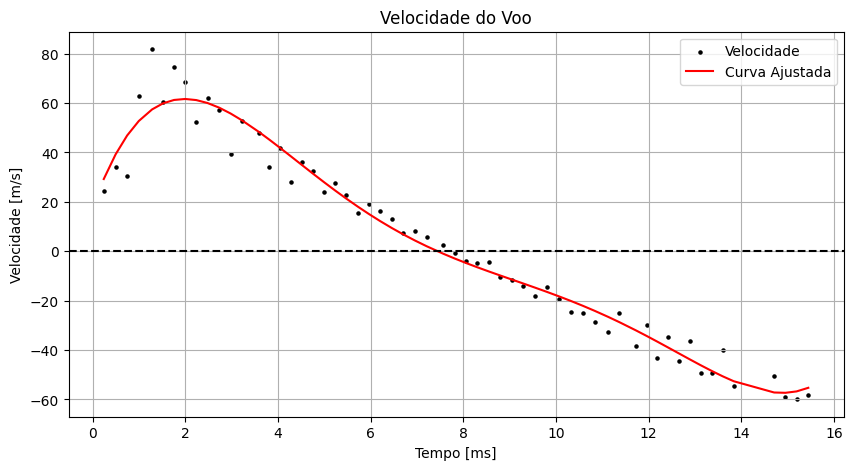

In [26]:
df_filtered['velocidade'] = df_filtered['altp'].diff() / df_filtered['millis'].diff()

# remove nan line
df_filtered = df_filtered.dropna(subset=['velocidade'])
# df_filtered['velocidade'] = df_filtered['velocidade'].abs()


def fit_curve(tempo, velocidade):
    def objective(x, a, b, c, d, e, f):
        return (a * x) + (b * x**2) + (c * x**3) + (d * x**4) + (e * x**5) + f

    popt, _ = curve_fit(objective, tempo, velocidade)
    return popt


def generate_curve(popt, x_values):
    a, b, c, d, e, f = popt
    return [(a * x) + (b * x**2) + (c * x**3) + (d * x**4) + (e * x**5) + f for x in x_values], x_values


popt = fit_curve(df_filtered['millis'], df_filtered['velocidade'])
fitted_curve, xfitted = generate_curve(popt, df_filtered['millis'])

plt.figure(figsize=(10, 5))
plt.scatter(df_filtered['millis'], df_filtered['velocidade'], label='Velocidade', color='black', s=5)
plt.plot(xfitted, fitted_curve, label='Curva Ajustada', color='red')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Velocidade do Voo')
plt.xlabel('Tempo [ms]')
plt.ylabel('Velocidade [m/s]')
plt.legend()
plt.grid()
plt.show()

---

Posição x,y

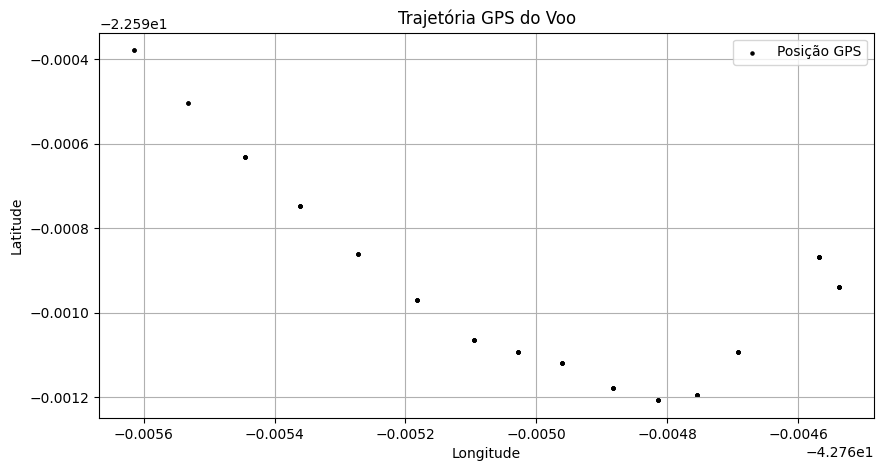

In [27]:
plt.figure(figsize=(10, 5))
plt.scatter(df_filtered['lon'], df_filtered['lat'], label='Posição GPS', color='black', s=5)
plt.title('Trajetória GPS do Voo')
plt.ylabel('Latitude')
plt.xlabel('Longitude')
plt.legend()
plt.grid()
plt.show()

---

Dados do acelerômetro

- Considerando o foguete "em pé", a ação da gravidade é na direção negativa do eixo Y

In [28]:
df['ay'].mean()

np.float64(8.169791666666669)

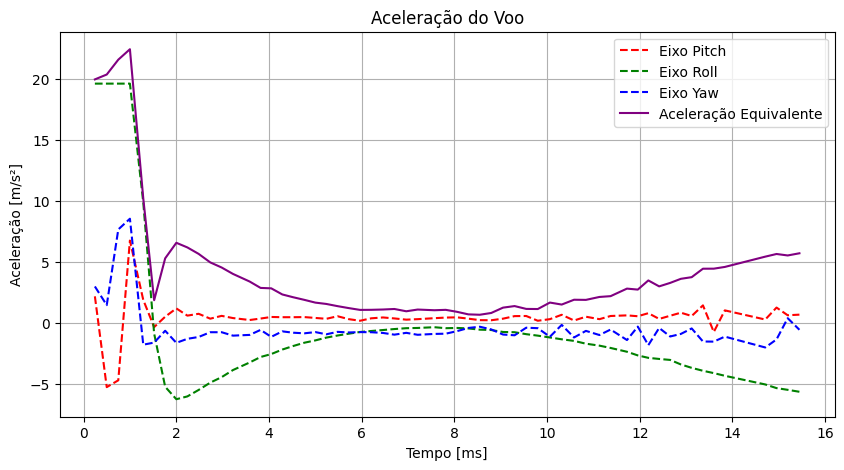

In [29]:
# Equivalente das acelerações 
def acceleration_equivalent(ax, ay, az):
    return (ax**2 + ay**2 + az**2)**0.5

plt.figure(figsize=(10, 5))
plt.plot(df_filtered['millis'], df_filtered['ax'], '--',label='Eixo Pitch', color='red') # Pitch axis
plt.plot(df_filtered['millis'], df_filtered['ay'], '--', label='Eixo Roll', color='green') # Roll axis
plt.plot(df_filtered['millis'], df_filtered['az'], '--', label='Eixo Yaw', color='blue') # Yaw axis
df_filtered['acc_equiv'] = acceleration_equivalent(df_filtered['ax'], df_filtered['ay'], df_filtered['az'])
plt.plot(df_filtered['millis'], df_filtered['acc_equiv'], label='Aceleração Equivalente', color='purple')
plt.title('Aceleração do Voo')
plt.xlabel('Tempo [ms]')
plt.ylabel('Aceleração [m/s²]')
plt.legend()
plt.grid()
plt.show()

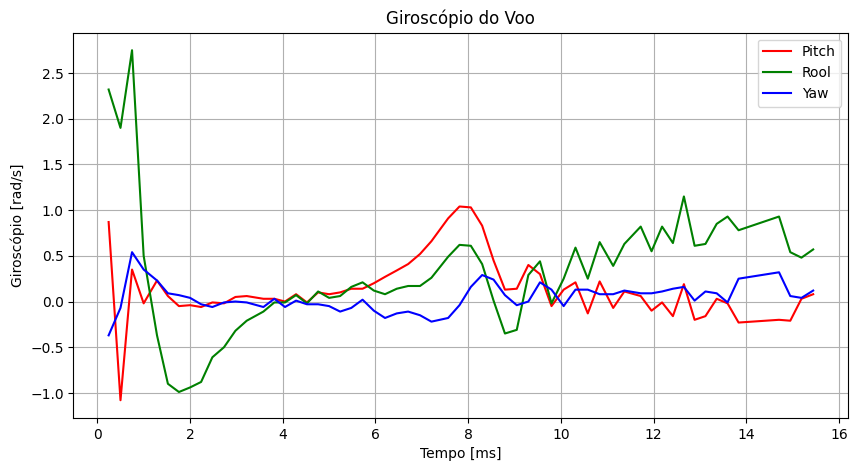

In [30]:
plt.figure(figsize=(10, 5))
plt.plot(df_filtered['millis'], df_filtered['gx'], label='Pitch', color='red') # Pitch axis
plt.plot(df_filtered['millis'], df_filtered['gy'], label='Rool', color='green') # Roll axis
plt.plot(df_filtered['millis'], df_filtered['gz'], label='Yaw', color='blue') # Yaw axis
plt.title('Giroscópio do Voo')
plt.xlabel('Tempo [ms]')
plt.ylabel('Giroscópio [rad/s]')
plt.legend()
plt.grid()
plt.show()

In [ ]:
def detect_motor_burnout(_pressure, height, state_vector, u_dot):
    """Detect motor burnout by sudden drop in acceleration.

    Returns True when vertical acceleration becomes significantly negative
    (indicating end of propulsion phase) OR when total acceleration drops below
    a threshold indicating coasting/free-fall has begun.
    """
    try:
        if u_dot is None or len(u_dot) < 6:
            return False

        ax = float(u_dot[3])
        ay = float(u_dot[4])
        az = float(u_dot[5])

        # Defensive checks for NaN/Inf
        if not all(np.isfinite([ax, ay, az])):
            return False

        total_acc = np.sqrt(ax * ax + ay * ay + az * az)
        if not np.isfinite(total_acc):
            return False

        # Additional safety: ignore spurious low-accel readings at t~0 by
        # requiring the rocket to be above a small altitude and still ascending
        vz = float(state_vector[5]) if len(state_vector) > 5 else 0
        if not np.isfinite(vz):
            return False

        if height < 5.0 or vz <= 0.5:
            return False

        # Burnout detected when:
        # 1. Vertical acceleration becomes very negative (end of thrust phase)
        # 2. OR total acceleration drops below 2.0 m/s² (coasting detected)
        return az < -8.0 or total_acc < 2.0
    except (ValueError, TypeError, IndexError):
        return False


def detect_apogee_acceleration(_pressure, _height, state_vector, u_dot):
    """Detect apogee using near-zero vertical velocity and negative vertical accel.

    Apogee occurs when the rocket reaches its highest point, characterized by
    vertical velocity approaching zero and negative (downward) acceleration.
    """
    try:
        if state_vector is None or u_dot is None:
            return False
        if len(state_vector) < 6 or len(u_dot) < 6:
            return False

        vz = float(state_vector[5])
        az = float(u_dot[5])
        if not all(np.isfinite([vz, az])):
            return False

        # Slightly more permissive thresholds to avoid spurious misses
        return abs(vz) < 1.0 and az < -0.1
    except (ValueError, TypeError, IndexError):
        return False


def detect_freefall(_pressure, height, state_vector, u_dot):
    """Detect free-fall when total acceleration magnitude is low.

    Free-fall is characterized by acceleration magnitude close to gravitational
    acceleration (approximately -g in the vertical direction), or when the rocket
    is in a ballistic coasting phase with minimal thrust or drag effects.
    """
    try:
        if u_dot is None or len(u_dot) < 6:
            return False

        ax = float(u_dot[3])
        ay = float(u_dot[4])
        az = float(u_dot[5])
        if not all(np.isfinite([ax, ay, az])):
            return False

        total_acc = np.sqrt(ax * ax + ay * ay + az * az)
        if not np.isfinite(total_acc):
            return False

        # Require the rocket to be descending and above a small altitude to
        # avoid false positives before launch.
        vz = float(state_vector[5]) if len(state_vector) > 5 else 0
        if not np.isfinite(vz):
            return False

        if height < 5.0 or vz >= -0.2:
            return False

        # More sensitive threshold: detect free-fall at lower acceleration
        return total_acc < 11.5 and vz < -5
    except (ValueError, TypeError, IndexError):
        return False


def detect_liftoff(_pressure, _height, _state_vector, u_dot):
    """Detect liftoff by high total acceleration.

    Liftoff is characterized by a sudden increase in acceleration as the motor
    ignites and begins producing thrust.
    """
    try:
        if u_dot is None or len(u_dot) < 6:
            return False

        ax = float(u_dot[3])
        ay = float(u_dot[4])
        az = float(u_dot[5])
        if not all(np.isfinite([ax, ay, az])):
            return False

        total_acc = np.sqrt(ax * ax + ay * ay + az * az)
        if not np.isfinite(total_acc):
            return False

        return total_acc > 15.0
    except (ValueError, TypeError, IndexError):
        return False


def altitude_trigger_factory(target_altitude, require_descent=True):
    """Return a trigger that deploys when altitude <= target_altitude.

    If require_descent is True, also require vertical velocity negative
    (descending) to avoid firing during ascent.
    """

    def trigger(_pressure, height, state_vector, _u_dot=None):
        vz = float(state_vector[5])
        if require_descent:
            return (height <= target_altitude) and (vz < 0)
        return height <= target_altitude

    return trigger


PARACHUTE_ALTITUDE = 100


def test_triggers_from_csv():

    df = df_filtered.reset_index(drop=True)

    parachute_trigger = altitude_trigger_factory(PARACHUTE_ALTITUDE)

    liftoff = False
    burnout = False
    apogee = False
    freefall = False
    parachute = False

    for i, row in df.iterrows():

        height = float(row["altp"])
        millis = float(row["millis"])

        ax = float(row["ax"])
        ay = float(row["ay"])
        az = float(row["az"])

        # velocidade vertical estimada
        if i == 0:
            vz = 0
        else:
            prev_alt = float(df.iloc[i - 1]["altp"])
            prev_time = float(df.iloc[i - 1]["millis"])

            dt = millis - prev_time

            if dt <= 0:
                vz = 0
            else:
                vz = (height - prev_alt) / dt
                vz = np.clip(vz, -200, 200)

        state_vector = [0, 0, height, 0, 0, vz]
        u_dot = [0, 0, 0, ax, ay, az]

        if not liftoff and detect_liftoff(None, height, state_vector, u_dot):
            print(
                f"LIFTOFF detectado em {millis:.2f} s | altura {height:.2f} | vz {vz:.2f} | ax {ax:.2f} | ay {ay:.2f} | az {az:.2f} | acc {np.sqrt(ax*ax + ay*ay + az*az):.2f}"
            )
            liftoff = True

        if not burnout and detect_motor_burnout(None, height, state_vector, u_dot):
            print(
                f"BURNOUT detectado em {millis:.2f} s | altura {height:.2f} | vz {vz:.2f} | ax {ax:.2f} | ay {ay:.2f} | az {az:.2f} | acc {np.sqrt(ax*ax + ay*ay + az*az):.2f}"
            )
            burnout = True

        if not apogee and detect_apogee_acceleration(None, height, state_vector, u_dot):
            print(
                f"APOGEE detectado em {millis:.2f} s | altura {height:.2f} | vz {vz:.2f} | ax {ax:.2f} | ay {ay:.2f} | az {az:.2f} | acc {np.sqrt(ax*ax + ay*ay + az*az):.2f}"
            )
            apogee = True

        if not freefall and detect_freefall(None, height, state_vector, u_dot):
            print(
                f"FREEFALL detectado em {millis:.2f} s | altura {height:.2f} | vz {vz:.2f} | ax {ax:.2f} | ay {ay:.2f} | az {az:.2f} | acc {np.sqrt(ax*ax + ay*ay + az*az):.2f}"
            )
            freefall = True

        if not parachute and parachute_trigger(None, height, state_vector):
            print(
                f"PARACHUTE trigger em {millis:.2f} s | altura {height:.2f} | vz {vz:.2f} | ax {ax:.2f} | ay {ay:.2f} | az {az:.2f} | acc {np.sqrt(ax*ax + ay*ay + az*az):.2f}"
            )
            parachute = True

test_triggers_from_csv()

LIFTOFF detectado em 0.24 s | altura 8.23 | vz 0.00 | ax 2.18 | ay 19.61 | az 2.99 | acc 19.96
BURNOUT detectado em 1.52 s | altura 78.05 | vz 60.21 | ax -0.34 | ay -0.87 | az -1.61 | acc 1.86
APOGEE detectado em 7.81 s | altura 274.01 | vz -0.90 | ax 0.44 | ay -0.43 | az -0.88 | acc 1.07
FREEFALL detectado em 8.79 s | altura 268.17 | vz -10.49 | ax 0.22 | ay -0.58 | az -0.53 | acc 0.82
PARACHUTE trigger em 14.71 s | altura 65.33 | vz -50.58 | ax 0.28 | ay -5.04 | az -2.01 | acc 5.43


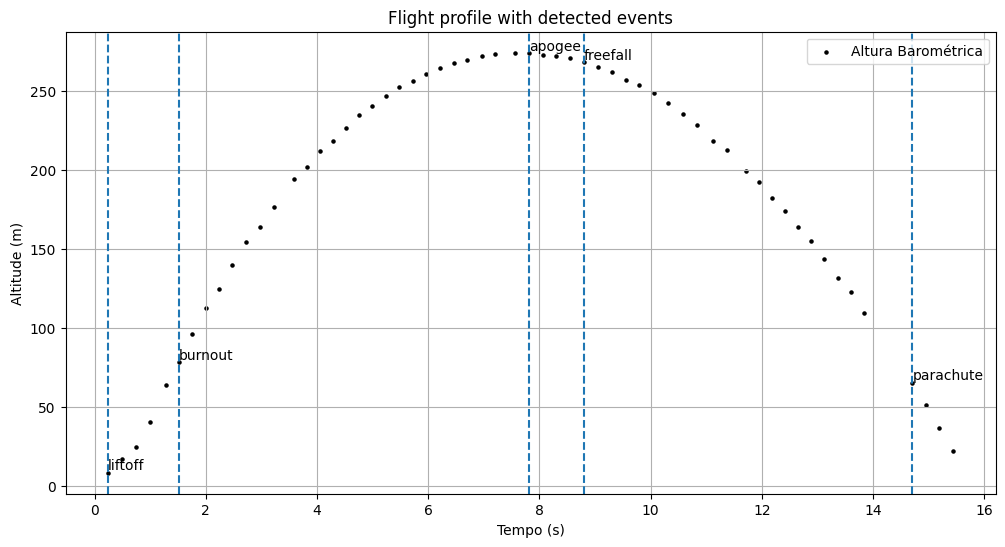

In [32]:
df = df_filtered.reset_index(drop=True).copy()

PARACHUTE_ALTITUDE = 100
parachute_trigger = altitude_trigger_factory(PARACHUTE_ALTITUDE)

df["vz"] = 0
df["event"] = ""

liftoff = False
burnout = False
apogee = False
freefall = False
parachute = False

for i, row in df.iterrows():

    height = float(row["altp"])
    millis = float(row["millis"])

    ax = float(row["ax"])
    ay = float(row["ay"])
    az = float(row["az"])

    # velocidade vertical
    if i == 0:
            vz = 0
    else:
        prev_alt = float(df.iloc[i - 1]["altp"])
        prev_time = float(df.iloc[i - 1]["millis"])

        dt = millis - prev_time

        if dt <= 0:
            vz = 0
        else:
            vz = (height - prev_alt) / dt
            vz = np.clip(vz, -200, 200)

    state_vector = [0, 0, height, 0, 0, vz]
    u_dot = [0, 0, 0, ax, ay, az]

    if not liftoff and detect_liftoff(None, height, state_vector, u_dot):
        df.loc[i, "event"] = "liftoff"
        liftoff = True

    elif not burnout and detect_motor_burnout(None, height, state_vector, u_dot):
        df.loc[i, "event"] = "burnout"
        burnout = True

    elif not apogee and detect_apogee_acceleration(None, height, state_vector, u_dot):
        df.loc[i, "event"] = "apogee"
        apogee = True

    elif not freefall and detect_freefall(None, height, state_vector, u_dot):
        df.loc[i, "event"] = "freefall"
        freefall = True

    elif not parachute and parachute_trigger(None, height, state_vector):
        df.loc[i, "event"] = "parachute"
        parachute = True

plt.figure(figsize=(12,6))

plt.scatter(df_filtered['millis'], df_filtered['altp'], label='Altura Barométrica', color='black', s=5)

events = df[df["event"] != ""]

for _, row in events.iterrows():

    t = row["millis"]
    e = row["event"]

    plt.axvline(t, linestyle="--")

    plt.text(
        t,
        row["altp"],
        e,
        rotation=0,
        verticalalignment="bottom"
    )

plt.xlabel("Tempo (s)")
plt.ylabel("Altitude (m)")
plt.title("Flight profile with detected events")

plt.grid(True)
plt.legend()

plt.show()

# 🧠 Estados do voo

Sugestão simples e robusta:

```
IDLE
↓
POWERED_ASCENT
↓
COAST
↓
DESCENT
↓
PARACHUTE_DEPLOYED
↓
LANDED
```

---

# 📊 Transições baseadas nos triggers

| Estado        | Condição             | Próximo estado     |
| ------------------ | -------------------- | ------------------ |
| IDLE               | detect_liftoff       | POWERED_ASCENT     |
| POWERED_ASCENT     | detect_motor_burnout | COAST              |
| COAST              | detect_apogee        | DESCENT            |
| DESCENT            | altitude_trigger     | PARACHUTE_DEPLOYED |
| PARACHUTE_DEPLOYED | vz ≈ 0 por tempo     | LANDED             |

---

# 💻 Estrutura básica em Python (equivalente ao que rodará no ESP32)

```python
from enum import Enum

class FlightState(Enum):
    IDLE = 0
    POWERED_ASCENT = 1
    COAST = 2
    DESCENT = 3
    PARACHUTE_DEPLOYED = 4
    LANDED = 5


state = FlightState.IDLE


def update_state(height, state_vector, u_dot):

    global state

    if state == FlightState.IDLE:

        if detect_liftoff(None, height, state_vector, u_dot):
            state = FlightState.POWERED_ASCENT
            print("STATE -> POWERED_ASCENT")

    elif state == FlightState.POWERED_ASCENT:

        if detect_motor_burnout(None, height, state_vector, u_dot):
            state = FlightState.COAST
            print("STATE -> COAST")

    elif state == FlightState.COAST:

        if detect_apogee_acceleration(None, height, state_vector, u_dot):
            state = FlightState.DESCENT
            print("STATE -> DESCENT")

    elif state == FlightState.DESCENT:

        if parachute_trigger(None, height, state_vector):
            state = FlightState.PARACHUTE_DEPLOYED
            print("STATE -> PARACHUTE_DEPLOYED")

    elif state == FlightState.PARACHUTE_DEPLOYED:

        vz = state_vector[5]

        if abs(vz) < 0.5 and height < 5:
            state = FlightState.LANDED
            print("STATE -> LANDED")
```

---

# 🔧 Versão equivalente para ESP32 (C++ / Arduino)

```cpp
enum FlightState {
    IDLE,
    POWERED_ASCENT,
    COAST,
    DESCENT,
    PARACHUTE_DEPLOYED,
    LANDED
};

FlightState state = IDLE;
```

Loop principal:

```cpp
switch(state) {

case IDLE:
    if(detect_liftoff(...)) {
        state = POWERED_ASCENT;
    }
    break;

case POWERED_ASCENT:
    if(detect_motor_burnout(...)) {
        state = COAST;
    }
    break;

case COAST:
    if(detect_apogee(...)) {
        state = DESCENT;
    }
    break;

case DESCENT:
    if(parachute_trigger(...)) {
        deploy_parachute();
        state = PARACHUTE_DEPLOYED;
    }
    break;

case PARACHUTE_DEPLOYED:
    if(abs(vz) < 0.5 && height < 5) {
        state = LANDED;
    }
    break;

}
```

---

# ⚠️ 3 proteções MUITO recomendadas em flight computers

### 1️⃣ Persistência (anti-ruído)

Exigir trigger por **N leituras seguidas**.

Exemplo:

```
3–5 ciclos
```

---

### 2️⃣ Tempo mínimo entre estados

Evita glitches:

```
liftoff → burnout mínimo 0.5 s
burnout → apogee mínimo 1 s
```

---

### 3️⃣ Armamento do parachute

Nunca permitir parachute antes de:

```
altura > 50 m
```

ou:

```
estado == DESCENT
```

---

# 🚀 Arquitetura final recomendada

```
Sensors
  ↓
Filtering
  ↓
State Machine
  ↓
Events
  ↓
Actuators
(parachute / logging / telemetry)
```

---

# ⭐ Dica extremamente importante para ESP32

No voo, **não use float pesado demais** em loops rápidos.

Preferir:

```
float ok
double desnecessário
```

E calcular apenas o necessário.


Sim — **ruído é provavelmente o maior problema em flight computers**. Sensores reais (IMU e barômetro) sempre têm **ruído, drift e spikes**, e sem tratamento isso pode disparar triggers falsos. 🚀

No seu caso (ESP32 + sensores de voo), vale se preocupar com **3 tipos principais de ruído**.

---

# 1️⃣ Ruído do acelerômetro (IMU)

Mesmo parado, o acelerômetro pode mostrar algo como:

```
ax = 0.3
ay = -0.7
az = 9.5
```

Isso acontece por:

* vibração do motor
* ruído elétrico
* quantização do sensor
* alinhamento imperfeito

Durante o voo isso fica ainda pior por causa da **vibração do motor**.

### Solução comum: média móvel

No ESP32 você pode usar algo simples:

```cpp
float smooth(float new_value, float prev_value, float alpha) {
    return alpha * new_value + (1 - alpha) * prev_value;
}
```

Uso:

```cpp
az_filtered = smooth(az_raw, az_filtered, 0.2);
```

Isso é um **low-pass filter exponencial**.

---

# 2️⃣ Ruído da altitude (barômetro)

Barômetros costumam ter:

```
±0.3 m até ±1.5 m
```

Isso causa:

* velocidade vertical ruidosa
* falso apogeu

Exemplo real:

```
alt: 273.9
alt: 274.1
alt: 273.8
alt: 274.0
```

Se calcular velocidade:

```
+0.2
-0.3
+0.2
```

Isso pode confundir triggers.

### Solução: filtrar altitude

Mesmo filtro exponencial funciona bem:

```cpp
alt_filtered = smooth(alt_raw, alt_filtered, 0.1);
```

---

# 3️⃣ Derivadas amplificam ruído

Quando você calcula:

```
vz = d(altitude)/dt
```

o ruído **aumenta muito**.

Por isso normalmente:

```
filtrar altitude → depois calcular velocidade
```

---

# 🧠 Estratégia recomendada para seu flight computer

Pipeline típico:

```
sensores
   ↓
filtro simples
   ↓
calcular vz
   ↓
máquina de estados
   ↓
triggers
```

---

# ⭐ Técnica MUITO usada em flight computers

Em vez de confiar em um único frame, exigir **persistência**.

Exemplo:

```cpp
if(detect_apogee(...)) {
    counter++;
} else {
    counter = 0;
}

if(counter >= 5) {
    state = DESCENT;
}
```

Isso exige **5 leituras seguidas**.

Se você roda a **100 Hz**:

```
5 leituras = 50 ms
```

Muito robusto contra ruído.

---

# 📊 Outra proteção útil: limites físicos

Ignorar valores absurdos:

```cpp
if(abs(vz) > 300) ignore
```

ou:

```cpp
if(acc_total > 100) ignore
```

---

# 🚀 Configuração típica em foguetes amadores

Taxa de leitura:

```
IMU → 100–500 Hz
Barômetro → 25–50 Hz
```

Filtros:

```
EMA alpha ≈ 0.1–0.3
```

Persistência de trigger:

```
3–10 ciclos
```

---

# ⚠️ Problema clássico de foguetes

Durante a **queima do motor**, vibração pode causar:

```
acc spikes
barometer noise
```

Por isso muitos sistemas:

```
ignoram barômetro até burnout
```

e usam apenas IMU durante powered flight.

---

# 🎯 Resumo prático para seu ESP32

Faça pelo menos:

✔ filtro exponencial para **aceleração**
✔ filtro exponencial para **altitude**
✔ persistência de **3–5 ciclos** para triggers
✔ limites físicos para ignorar absurdos


Um **filtro de Kalman** é muito usado em rocketry para **estimar altitude e velocidade a partir de sensores ruidosos** (IMU + barômetro). Ele combina medições e modelo de movimento, suavizando ruído e ainda fornecendo **velocidade confiável**. 🚀

Vou explicar de forma prática, com foco no **ESP32**.

---

# 1️⃣ Modelo simplificado do Kalman para foguete

Para um foguete vertical, podemos modelar o estado assim:

[
X =
\begin{bmatrix}
h \ v
\end{bmatrix}
=============

\begin{bmatrix}
altura \ velocidade
\end{bmatrix}
]

O sistema discreto é:

[
X_{k+1} =
\begin{bmatrix}
1 & dt \
0 & 1
\end{bmatrix} X_k +
\begin{bmatrix}
0.5 dt^2 \ dt
\end{bmatrix} a_k
]

* (a_k) → aceleração medida (IMU)
* (h) → altura estimada
* (v) → velocidade estimada

A **medição** vem do barômetro:

[
z_k = h_{baro} + \text{ruído}
]

---

# 2️⃣ Passos do filtro de Kalman

1. **Predição**

[
\hat{X}*{k|k-1} = F \hat{X}*{k-1|k-1} + B a
]

[
P_{k|k-1} = F P_{k-1|k-1} F^T + Q
]

* `F` = matriz de transição
* `B` = matriz de controle (aceleração)
* `P` = covariância do estado
* `Q` = ruído do modelo

---

2. **Atualização com medição**

[
K_k = P_{k|k-1} H^T (H P_{k|k-1} H^T + R)^{-1}
]

[
\hat{X}*{k|k} = \hat{X}*{k|k-1} + K_k (z_k - H \hat{X}_{k|k-1})
]

[
P_{k|k} = (I - K_k H) P_{k|k-1}
]

* `H` = matriz de medição → `[1 0]` (somente altura)
* `R` = ruído do sensor (barômetro)

---

# 3️⃣ Implementação simples em Python

```python
import numpy as np

# Inicialização
dt = 0.01  # tempo entre leituras, s
X = np.array([[0.0], [0.0]])  # estado inicial [h, v]
P = np.eye(2) * 1.0           # covariância inicial

F = np.array([[1, dt],
              [0, 1]])
B = np.array([[0.5*dt**2],
              [dt]])
H = np.array([[1, 0]])
Q = np.array([[0.01, 0],
              [0, 0.01]])  # ruído do modelo
R = np.array([[1.0]])      # ruído do sensor

def kalman_predict(a):
    global X, P
    X = F @ X + B * a
    P = F @ P @ F.T + Q

def kalman_update(h_measured):
    global X, P
    y = np.array([[h_measured]]) - H @ X
    S = H @ P @ H.T + R
    K = P @ H.T @ np.linalg.inv(S)
    X = X + K @ y
    P = (np.eye(2) - K @ H) @ P

# Exemplo de uso em loop:
for t, (a_meas, h_baro) in enumerate(sensor_data):
    kalman_predict(a_meas)
    kalman_update(h_baro)
    h_est = X[0,0]
    v_est = X[1,0]
```

---

# 4️⃣ Benefícios no ESP32

* `h_est` → altura filtrada, suave
* `v_est` → velocidade vertical confiável, mesmo com barômetro ruidoso
* roda bem em **float 32 bits**, super leve
* evita spikes falsos nos triggers de burnout/apogee/parachute

---

# 5️⃣ Implementação em C++ / Arduino (ESP32)

No ESP32 basta traduzir matrizes 2x2 e vetores 2x1:

```cpp
float X[2] = {0, 0};
float P[2][2] = {{1,0},{0,1}};
float F[2][2] = {{1, dt},{0,1}};
float B[2] = {0.5*dt*dt, dt};
float H[2] = {1, 0};
float Q[2][2] = {{0.01,0},{0,0.01}};
float R = 1.0;

void kalman_predict(float a){
    float X_new[2];
    X_new[0] = F[0][0]*X[0] + F[0][1]*X[1] + B[0]*a;
    X_new[1] = F[1][0]*X[0] + F[1][1]*X[1] + B[1]*a;
    X[0] = X_new[0];
    X[1] = X_new[1];
    // P update simplificado para 2x2
}

void kalman_update(float h_meas){
    float y = h_meas - (H[0]*X[0] + H[1]*X[1]);
    float S = H[0]*P[0][0]*H[0] + R;
    float K0 = P[0][0]*H[0]/S;
    float K1 = P[1][0]*H[0]/S;
    X[0] += K0 * y;
    X[1] += K1 * y;
    P[0][0] *= (1-K0*H[0]);
    P[1][1] *= (1-K1*H[1]);
}
```

---

# ⚠️ Dicas finais

1. `Q` → quanto maior, mais “confiança” no sensor; ajusta suavidade
2. `R` → quanto maior, mais confiança no modelo e menos nas medições
3. `dt` → use a taxa real do seu sensor
4. Com IMU + barômetro, Kalman faz **apogeu e burnout muito mais confiáveis**


dt médio = 0.2622 s


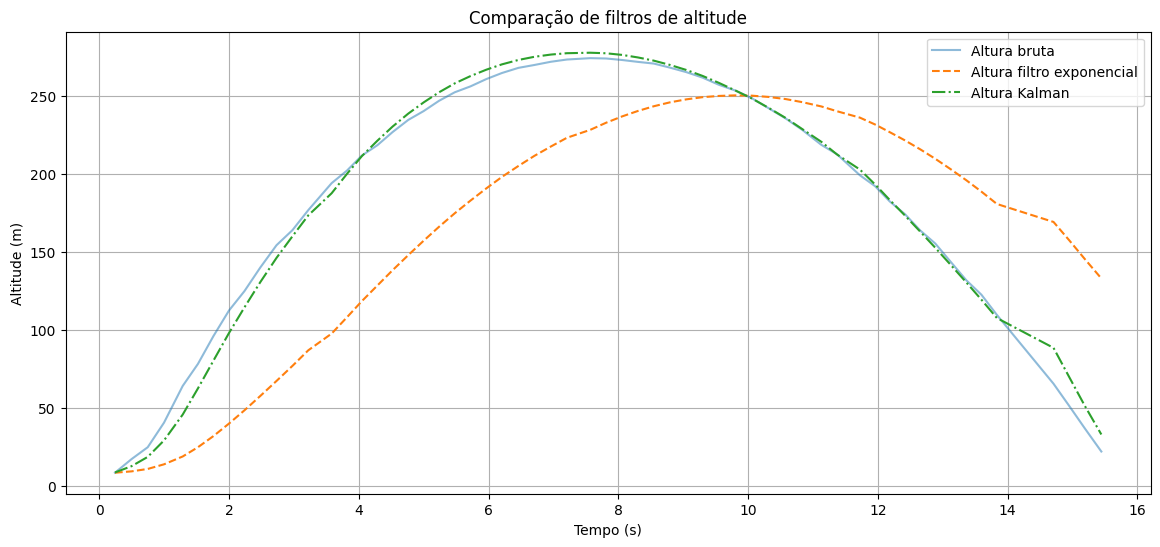

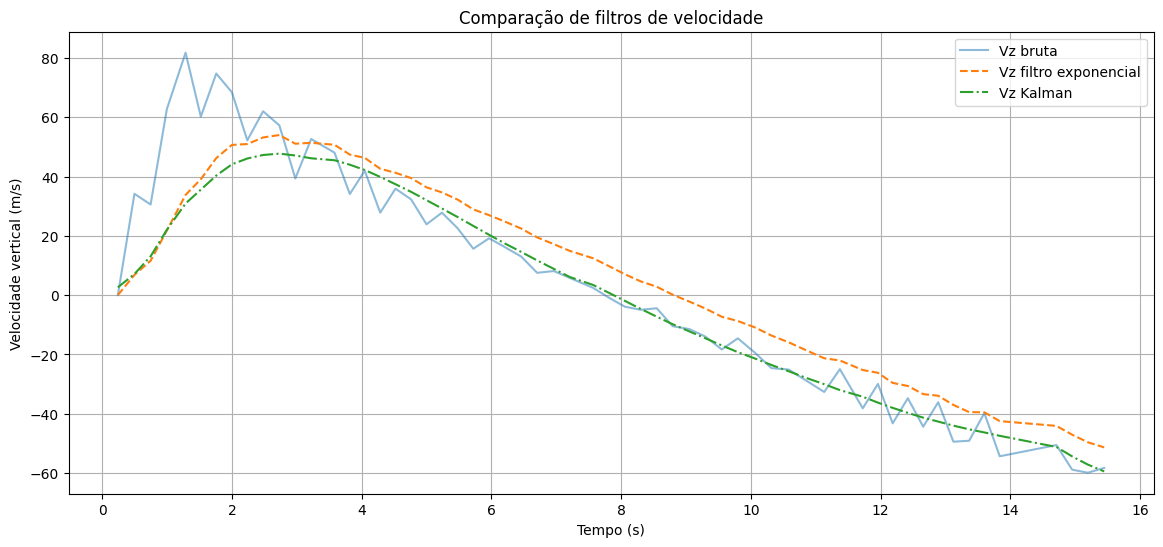

In [33]:
# Reset índice
df = df_filtered.reset_index(drop=True).copy()

# Tempo entre leituras
dt = np.mean(np.diff(df["millis"])) 
print(f"dt médio = {dt:.4f} s")

# Inicializações
n = len(df)
alt_raw = df["altp"].to_numpy()
ax = df["ax"].to_numpy()
ay = df["ay"].to_numpy()
az = df["az"].to_numpy()

# Velocidade aproximada via diferença de altitude
vz_raw = np.zeros(n)
for i in range(1, n):
    dt_i = (df.loc[i, "millis"] - df.loc[i-1, "millis"])
    vz_raw[i] = (alt_raw[i] - alt_raw[i-1]) / dt_i


# Suavização exponencial para altitude e velocidade
alpha_alt = 0.1
alpha_vz = 0.2

alt_smooth = np.zeros(n)
vz_smooth = np.zeros(n)

alt_smooth[0] = alt_raw[0]
vz_smooth[0] = vz_raw[0]

for i in range(1, n):
    alt_smooth[i] = alpha_alt * alt_raw[i] + (1 - alpha_alt) * alt_smooth[i-1]
    vz_smooth[i] = alpha_vz * vz_raw[i] + (1 - alpha_vz) * vz_smooth[i-1]


# Kalman Filter para altitude e velocidade vertical
X = np.array([[alt_raw[0]], [vz_raw[0]]])  # [altura, vz]
P = np.eye(2)
F = np.array([[1, dt],
              [0, 1]])
B = np.array([[0.5*dt**2],
              [dt]])
H = np.array([[1, 0]])
Q = np.array([[0.01, 0],
              [0, 0.01]])
R = np.array([[1.0]])

alt_kalman = np.zeros(n)
vz_kalman = np.zeros(n)

for i in range(n):
    a_total = np.sqrt(ax[i]**2 + ay[i]**2 + az[i]**2)
    
    # 1️⃣ predição
    X = F @ X + B * (a_total - 9.81)  # subtrair gravidade
    P = F @ P @ F.T + Q
    
    # 2️⃣ atualização com barômetro
    z = np.array([[alt_raw[i]]])
    y = z - H @ X
    S = H @ P @ H.T + R
    K = P @ H.T @ np.linalg.inv(S)
    X = X + K @ y
    P = (np.eye(2) - K @ H) @ P
    
    alt_kalman[i] = X[0,0]
    vz_kalman[i] = X[1,0]

plt.figure(figsize=(14,6))

plt.plot(df["millis"], alt_raw, label="Altura bruta", alpha=0.5)
plt.plot(df["millis"], alt_smooth, label="Altura filtro exponencial", linestyle="--")
plt.plot(df["millis"], alt_kalman, label="Altura Kalman", linestyle="-.")

plt.xlabel("Tempo (s)")
plt.ylabel("Altitude (m)")
plt.title("Comparação de filtros de altitude")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(14,6))
plt.plot(df["millis"], vz_raw, label="Vz bruta", alpha=0.5)
plt.plot(df["millis"], vz_smooth, label="Vz filtro exponencial", linestyle="--")
plt.plot(df["millis"], vz_kalman, label="Vz Kalman", linestyle="-.")

plt.xlabel("Tempo (s)")
plt.ylabel("Velocidade vertical (m/s)")
plt.title("Comparação de filtros de velocidade")
plt.legend()
plt.grid(True)
plt.show()

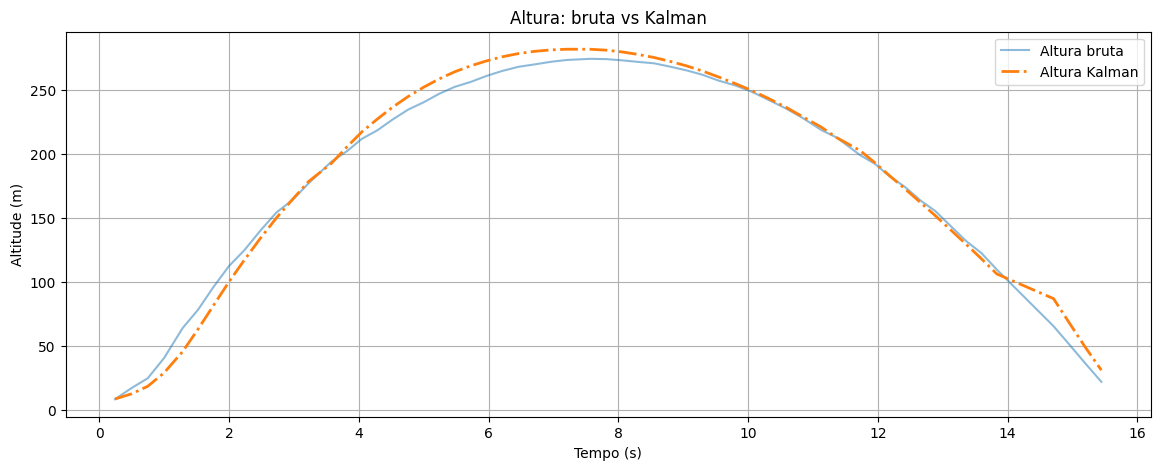

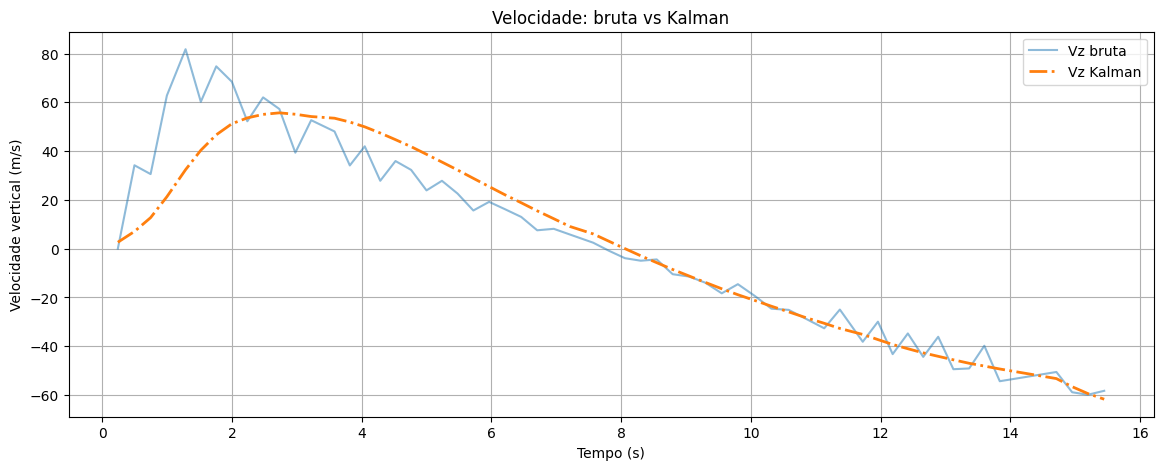

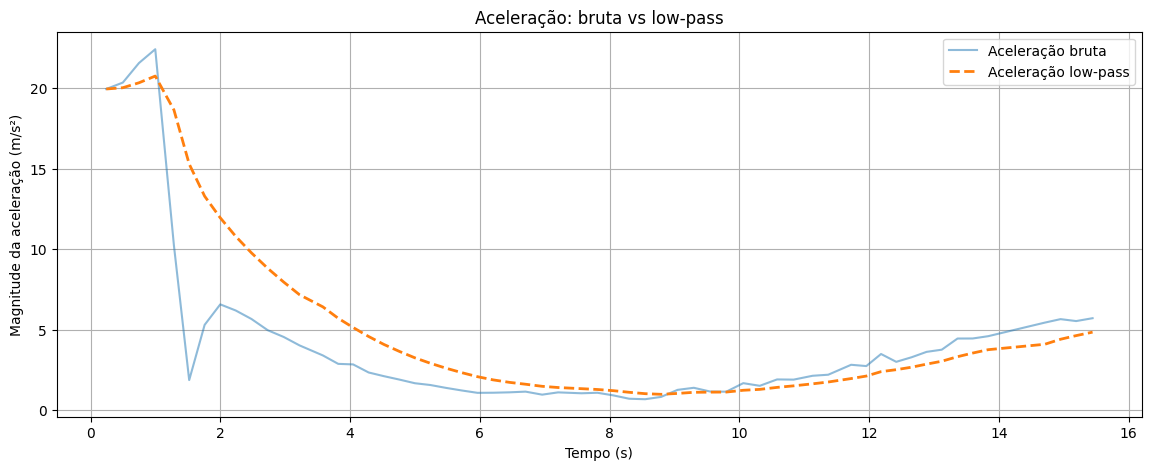

LIFTOFF detectado em 0.24 s | altura 8.40 | vz 2.62 | acc 19.96
BURNOUT detectado em 1.52 s | altura 62.86 | vz 40.34 | acc 15.29
APOGEE detectado em 8.06 s | altura 279.63 | vz 0.00 | acc 1.20
FREEFALL detectado em 8.55 s | altura 275.31 | vz -5.76 | acc 1.02
PARACHUTE trigger em 14.71 s | altura 86.85 | vz -53.29 | acc 4.09


In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Reset índice e copiar df_filtered
df = df_filtered.reset_index(drop=True).copy()

n = len(df)
time = df["millis"].to_numpy() # tempo em segundos

alt_raw = df["altp"].to_numpy()
ax = df["ax"].to_numpy()
ay = df["ay"].to_numpy()
az = df["az"].to_numpy()

# Velocidade aproximada via diferença de altitude
vz_raw = np.zeros(n)
for i in range(1, n):
    dt_i = time[i] - time[i-1]
    vz_raw[i] = (alt_raw[i] - alt_raw[i-1]) / dt_i

alpha_acc = 0.2  # ajuste conforme seu sensor

acc_raw = np.sqrt(ax**2 + ay**2 + az**2)
acc_lp = np.zeros(n)
acc_lp[0] = acc_raw[0]

for i in range(1, n):
    acc_lp[i] = alpha_acc * acc_raw[i] + (1 - alpha_acc) * acc_lp[i-1]

dt = np.mean(np.diff(time))  # média do dt

# Inicialização
X = np.array([[alt_raw[0]], [vz_raw[0]]])  # estado [h, vz]
P = np.eye(2)
F = np.array([[1, dt],
              [0, 1]])
B = np.array([[0.5*dt**2],
              [dt]])
H = np.array([[1, 0]])
Q = np.array([[0.01, 0],
              [0, 0.01]])  # ruído do modelo
R = np.array([[1.0]])      # ruído do barômetro

alt_kalman = np.zeros(n)
vz_kalman = np.zeros(n)

for i in range(n):
    # aceleração total medida subtrai gravidade
    a_total = acc_lp[i] - 9.81
    
    # 1️⃣ Predição
    X = F @ X + B * a_total
    P = F @ P @ F.T + Q
    
    # 2️⃣ Atualização
    z = np.array([[alt_raw[i]]])
    y = z - H @ X
    S = H @ P @ H.T + R
    K = P @ H.T @ np.linalg.inv(S)
    X = X + K @ y
    P = (np.eye(2) - K @ H) @ P
    
    alt_kalman[i] = X[0,0]
    vz_kalman[i] = X[1,0]

plt.figure(figsize=(14,5))
plt.plot(time, alt_raw, label="Altura bruta", alpha=0.5)
plt.plot(time, alt_kalman, label="Altura Kalman", linestyle="-.", linewidth=2)
plt.xlabel("Tempo (s)")
plt.ylabel("Altitude (m)")
plt.title("Altura: bruta vs Kalman")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14,5))
plt.plot(time, vz_raw, label="Vz bruta", alpha=0.5)
plt.plot(time, vz_kalman, label="Vz Kalman", linestyle="-.", linewidth=2)
plt.xlabel("Tempo (s)")
plt.ylabel("Velocidade vertical (m/s)")
plt.title("Velocidade: bruta vs Kalman")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14,5))
plt.plot(time, acc_raw, label="Aceleração bruta", alpha=0.5)
plt.plot(time, acc_lp, label="Aceleração low-pass", linestyle="--", linewidth=2)
plt.xlabel("Tempo (s)")
plt.ylabel("Magnitude da aceleração (m/s²)")
plt.title("Aceleração: bruta vs low-pass")
plt.grid(True)
plt.legend()
plt.show()

def test_triggers_from_csv_filtered():
    df = df_filtered.reset_index(drop=True)
    parachute_trigger = altitude_trigger_factory(PARACHUTE_ALTITUDE)

    liftoff = False
    burnout = False
    apogee = False
    freefall = False
    parachute = False

    for i, row in df.iterrows():
        millis = float(row["millis"])
        height = alt_kalman[i]      # usar altura filtrada
        vz = vz_kalman[i]           # usar velocidade filtrada
        a_total = acc_lp[i]         # magnitude da aceleração filtrada

        # Para triggers que usam ax, ay, az, podemos aproximar com:
        ax_i = ax[i]
        ay_i = ay[i]
        az_i = az[i]

        state_vector = [0, 0, height, 0, 0, vz]
        u_dot = [0, 0, 0, ax_i, ay_i, az_i]

        if not liftoff and detect_liftoff(None, height, state_vector, u_dot):
            print(
                f"LIFTOFF detectado em {millis:.2f} s | altura {height:.2f} | vz {vz:.2f} | acc {a_total:.2f}"
            )
            liftoff = True

        if not burnout and detect_motor_burnout(None, height, state_vector, u_dot):
            print(
                f"BURNOUT detectado em {millis:.2f} s | altura {height:.2f} | vz {vz:.2f} | acc {a_total:.2f}"
            )
            burnout = True

        if not apogee and detect_apogee_acceleration(None, height, state_vector, u_dot):
            print(
                f"APOGEE detectado em {millis:.2f} s | altura {height:.2f} | vz {vz:.2f} | acc {a_total:.2f}"
            )
            apogee = True

        if not freefall and detect_freefall(None, height, state_vector, u_dot):
            print(
                f"FREEFALL detectado em {millis:.2f} s | altura {height:.2f} | vz {vz:.2f} | acc {a_total:.2f}"
            )
            freefall = True

        if not parachute and parachute_trigger(None, height, state_vector):
            print(
                f"PARACHUTE trigger em {millis:.2f} s | altura {height:.2f} | vz {vz:.2f} | acc {a_total:.2f}"
            )
            parachute = True

# Rodar o teste com dados filtrados
test_triggers_from_csv_filtered()

## Antes
- LIFTOFF detectado em 0.24 s | altura 8.23 | vz 0.00 | acc 19.96
- BURNOUT detectado em 1.52 s | altura 78.05 | vz 60.21 | acc 1.86
- APOGEE detectado em 7.81 s | altura 274.01 | vz -0.90 | acc 1.07
- FREEFALL detectado em 8.79 s | altura 268.17 | vz -10.49 | acc 0.82
- PARACHUTE trigger em 14.71 s | altura 65.33 | vz -50.58 | acc 5.43

## Depois 
- LIFTOFF detectado em 0.24 s | altura 8.40 | vz 2.62 | acc 19.96
- BURNOUT detectado em 1.52 s | altura 62.86 | vz 40.34 | acc 15.29
- APOGEE detectado em 8.06 s | altura 279.63 | vz 0.00 | acc 1.20
- FREEFALL detectado em 8.55 s | altura 275.31 | vz -5.76 | acc 1.02
- PARACHUTE trigger em 14.71 s | altura 86.85 | vz -53.29 | acc 4.09

# 1️⃣ Por que filtrar a aceleração?

Sensores IMU (acelerômetros) apresentam:

* **ruído alto** (vibração, eletrônica)
* **offsets e drift**
* **picos falsos** durante queima do motor

Se você usar a aceleração **direto nos triggers** (`detect_motor_burnout`, `detect_liftoff`), ruído pode:

* causar **falsos positivos**
* ou atrasar a detecção (se usar média simples)

---

# 2️⃣ Como aplicar Kalman na aceleração

Existem duas formas comuns:

### A. Kalman **como sensor fusion** (mais usado)

* Use Kalman para **altura + velocidade**, alimentando com aceleração do IMU
* O próprio Kalman já “corrige” a aceleração de forma implícita, porque a aceleração entra na predição do estado.

Vantagem: você **não precisa filtrar aceleração separadamente** para triggers de altitude/velocidade.

---

### B. Kalman ou low-pass **direto na aceleração**

Se você ainda quer triggers que dependem da **magnitude da aceleração total**, pode aplicar um filtro leve:

* **Kalman simples 1D** (aceleração)

Estado:

[
X = a
]

Medição:

[
z = a_\text{IMU}
]

Predição: assume que aceleração não muda muito entre amostras.

Isso é útil se você quiser calcular **magnitude total de aceleração** sem spikes.

Exemplo Python simples:

```python
a_k = 0.0
P = 1.0
Q = 0.01
R = 0.1

for a_meas in acc_data:
    # predição
    a_pred = a_k
    P = P + Q

    # atualização
    K = P / (P + R)
    a_k = a_pred + K * (a_meas - a_pred)
    P = (1 - K) * P

    a_filtered.append(a_k)
```

✅ Isso remove **picos isolados** e mantém tendências reais.

---

# 3️⃣ Qual abordagem usar nos triggers?

| Trigger   | Melhor fonte                                     | Comentário                                          |
| --------- | ------------------------------------------------ | --------------------------------------------------- |
| Liftoff   | total acceleration filtrada (Kalman ou low-pass) | spikes do motor podem enganar                       |
| Burnout   | total acceleration **ou** vz Kalman              | usar vz + aceleração suavizada evita falso positivo |
| Apogee    | vz Kalman                                        | muito mais confiável que aceleração                 |
| Freefall  | vz + acc Kalman                                  | garante velocidade descendente e baixa aceleração   |
| Parachute | altitude Kalman                                  | alt + vz filtrados ajudam timing correto            |

---

# 4️⃣ Prática no ESP32

* Aceleração **não precisa de Kalman completo** se você já usa Kalman 2D para altitude + vz
* Pode fazer **low-pass rápido 1D** apenas para magnitude do vetor, com `alpha ≈ 0.1–0.2`
* Evita matemática pesada, mantém loop rápido (<1 ms)

---

💡 **Resumo:**

* Filtrar aceleração **é válido**
* Se você já tem Kalman para altura + velocidade, a aceleração usada nele já está implícita
* Caso precise do vetor de aceleração **para triggers diretos**, use **low-pass ou 1D Kalman leve**
